<a href="https://colab.research.google.com/github/RichaCui70/Dynamics-between-Seafood-Fraudsters-and-Buyers/blob/main/Interactions_between_Buyers%2C_Fraudsters%2C_and_Seafood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# <b>The nondimesionalized system</b>


## **Libraries, Parameters & Initial Values, and Equations as Functions**

Here, we introduce...

- The Python libraries used
- The initial parameter values
- The system as lambda equations (for calculations)
- The system as symbolic equations (for algebraic manipulations)
- Customized exceptions



In [ ]:
# %pip install SALib

import os
import sys
import warnings
import random
import numbers
import pickle
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d as plt3d
from matplotlib.patches import Patch
from skimage import measure
from scipy.spatial import cKDTree
from scipy.optimize import fsolve
from numpy.linalg import eigvals
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# import warnings
# warnings.filterwarnings("ignore")
bump = 1e-9
seafood_state = lambda S, E, gamma_s: S * np.exp(gamma_s * (1 - S - E))
def effort_state(E, S, F, q, pw, c, e_sw, gamma_p, gamma_e): 
    term_1 = (F * (pw - 1) + 1)
    denom_e = (gamma_p * E * S + bump) ** e_sw
    term_2 = (q * S * (term_1 / denom_e))
    term_3 = (F * (c - 1)) + 1
    
    return E * np.exp(gamma_e * (term_2 - term_3))
def fraudster_state(S, E, F, Fp, gamma_f, gamma_m, gamma_p, pw, e_sw, e_sm, e_d):
    denom_market = (E * S)**(e_sm/2) + bump
    price_market = gamma_m * ((1 - Fp)**(e_d/2) / denom_market)
    
    denom_wholesale = (gamma_p * E * S)**(e_sw) + bump
    price_wholesale = (F * (pw - 1) + 1) / denom_wholesale
    
    delta = gamma_f * (price_market - price_wholesale)
    if bump != 0:
        delta = np.clip(delta, -20, 20) # Prevent overflow
    return (F * np.exp(delta)) / (1 + F * (np.exp(delta) - 1))
def p_fraudster_state(F, Fp, F_threshold, gamma_fp): 
    delta_fp = gamma_fp * (F - F_threshold)
    exp_delta_fp = np.exp(delta_fp)
    
    return (Fp * exp_delta_fp) / (1 + Fp * (exp_delta_fp - 1))


    # Old parameters that are still relevant in the nondimensionalized system

old_params = {
    'q': 0.0002,
    'r': 0.02,
    'K': 1.0,
    'Pw1': 5,
    'Pw0': 1,
    'C1': 2,
    'C0': 1,
    'e_sm': 1.0,
}
# Nondimensionalized parameters
new_params = {
    'gamma_m': 1.0 / (old_params['Pw0'] * (old_params['r'] * old_params['K']) ** (old_params['e_sm'] / 2)), # gamma_m / (Pw0 * (r * K)^(e_sm / 2)...
    'gamma_f': 110 * old_params['Pw0'],                         # gamma_f * Pw0
    'gamma_s': 1.0 * old_params['r'],                           # gamma_s * r
    'gamma_e': 0.6 * old_params['C0'],                          # gamma_e * C0
    'gamma_p': 5000.0 * old_params['r'] * old_params['K'],         # gamma_s * r * K
    'e_sm': 1.0,
    'e_sw': 1.0,
    'e_d': 1.0,
    'F_threshold': 0.05,
    'q': (old_params['q'] * old_params['Pw0'] * old_params['K']) / old_params['C0'],        # (q * Pw0 * K) / C0
    'pw': old_params['Pw1']/old_params['Pw0'],                                              # Pw1/Pw0
    'c': old_params['C1']/old_params['C0'],                     # C1/C0
}
# Nondimensionalized parameters without worrying about their definitions
new_params_without_old_influence = {
    'gamma_m': 1.0, 
    'gamma_f': 2.0, 
    'gamma_s': 2.0,
    'gamma_e': 0.1,
    'gamma_p': 2.0,
    'gamma_fp': 5,
    'e_sm': 1.0, 
    'e_sw': 1.2,
    'e_d': 4.0, 
    'F_threshold': 0.2, 
    'q': 0.02,
    'pw': 5.0,
    'c': 3.0
}

new_params_without_old_influence = {
    'gamma_m': 1.0,
    'gamma_f': 5.0,
    'gamma_s': 1.0,
    'gamma_e': 1.2,
    'gamma_p': 11.0,
    'gamma_fp': 1.0,
    'q': 0.5,
    'e_d': 1.0,
    'e_sw': 1.0,
    'e_sm': 1.0,
    'F_threshold': 0.15,
    'pw': 6.0,
    'c': 3.0
}

# Initial starting values 
init_vals = [0.5, 0.5, 0.2, 0.5]

total_time = 50
bifurcation_transient = int(total_time - (0.25 * total_time))

## **Helper Functions: Plotting the Model**

Here, we introduce helper functions to assist in plotting the system using matplotlib


In [118]:
def line_graph(x_series, y_series, ax, **kwargs):
    """
    Creates a line graph in 2-D or 3-D (optional)

    Args:
        x_series (list[list[Number]]): Values along the x-axis.
        y_series (list[list[Number]]): Values along the y-axis. Same structure as `x_series`.
        ax (plt.Axes): Matplotlib Axes to build graph
        **kwargs: Additional keyword arguments containing graph metadata
            title (str): Title of the graph
            x_label (str): Label along x-axis
            y_label (str): Label along y-axis
            line_label (list[str]): Label(s) for the line(s)
            line_color (list[str]): Color(s) for the line(s)
            x_lim (tuple): The range of the x-axis
            y_lim (tuple): The range of the y-axis

    Returns:
        None
    """
    if not hasattr(x_series, '__iter__') or not hasattr(y_series, '__iter__'):
        raise Exception("x_series and y_series must be iterable")

    if len(x_series) != len(y_series) or len(x_series) == 0:
        raise Exception('x_series and y_series must not be empty')


    # Check if each element in the axis_series is an iterable
    if all(hasattr(a, '__iter__') for a in x_series) and all(hasattr(a, '__iter__') for a in y_series):
        # For each list within the axis_series, check if each element is a number
        if all(isinstance(a, numbers.Number) for sublist in x_series for a in sublist) and all(isinstance(a, numbers.Number) for sublist in y_series for a in sublist):
            # For each list within the axis_series, check if each the list matches the size of the list in the other axis_series
            if all(len(a) == len(b) for a, b in zip(x_series, y_series)):
                line_label_exists = 'line_label' in kwargs and len(kwargs['line_label']) == len(x_series) and all(isinstance(a, str) for a in kwargs['line_label'])
                line_color_exists = 'line_color' in kwargs and len(kwargs['line_color']) == len(x_series) and all(isinstance(a, str) for a in kwargs['line_color'])
                for i in range(len(x_series)):
                    ax.plot(
                    x_series[i],
                    y_series[i],
                    label=kwargs['line_label'][i]
                        if line_label_exists else None,
                    color=kwargs['line_color'][i]
                        if line_color_exists else None,
                    )
                    if line_label_exists:
                        ax.legend()
            else:
                raise Exception("x_series shape does not match y_series")
        else:
            raise Exception("Series elements aren't series of numbers")

    else:
        raise Exception("Series elements aren't iterable")

    if 'title' in kwargs:
      ax.set_title(kwargs['title'])
    if 'x_label' in kwargs:
      ax.set_xlabel(kwargs['x_label'])
    if 'y_label' in kwargs:
      ax.set_ylabel(kwargs['y_label'])
    if 'x_lim' in kwargs:
      ax.set_xlim(kwargs['x_lim'])
    if 'y_lim' in kwargs:
      ax.set_ylim(kwargs['y_lim'])

    ax.grid(True)


## **Time Series**


Generating Bifurcation Diagram for gamma_p...
Generating Bifurcation Diagram for gamma_p...
Generating Bifurcation Diagram for gamma_p...
Generating Bifurcation Diagram for gamma_p...


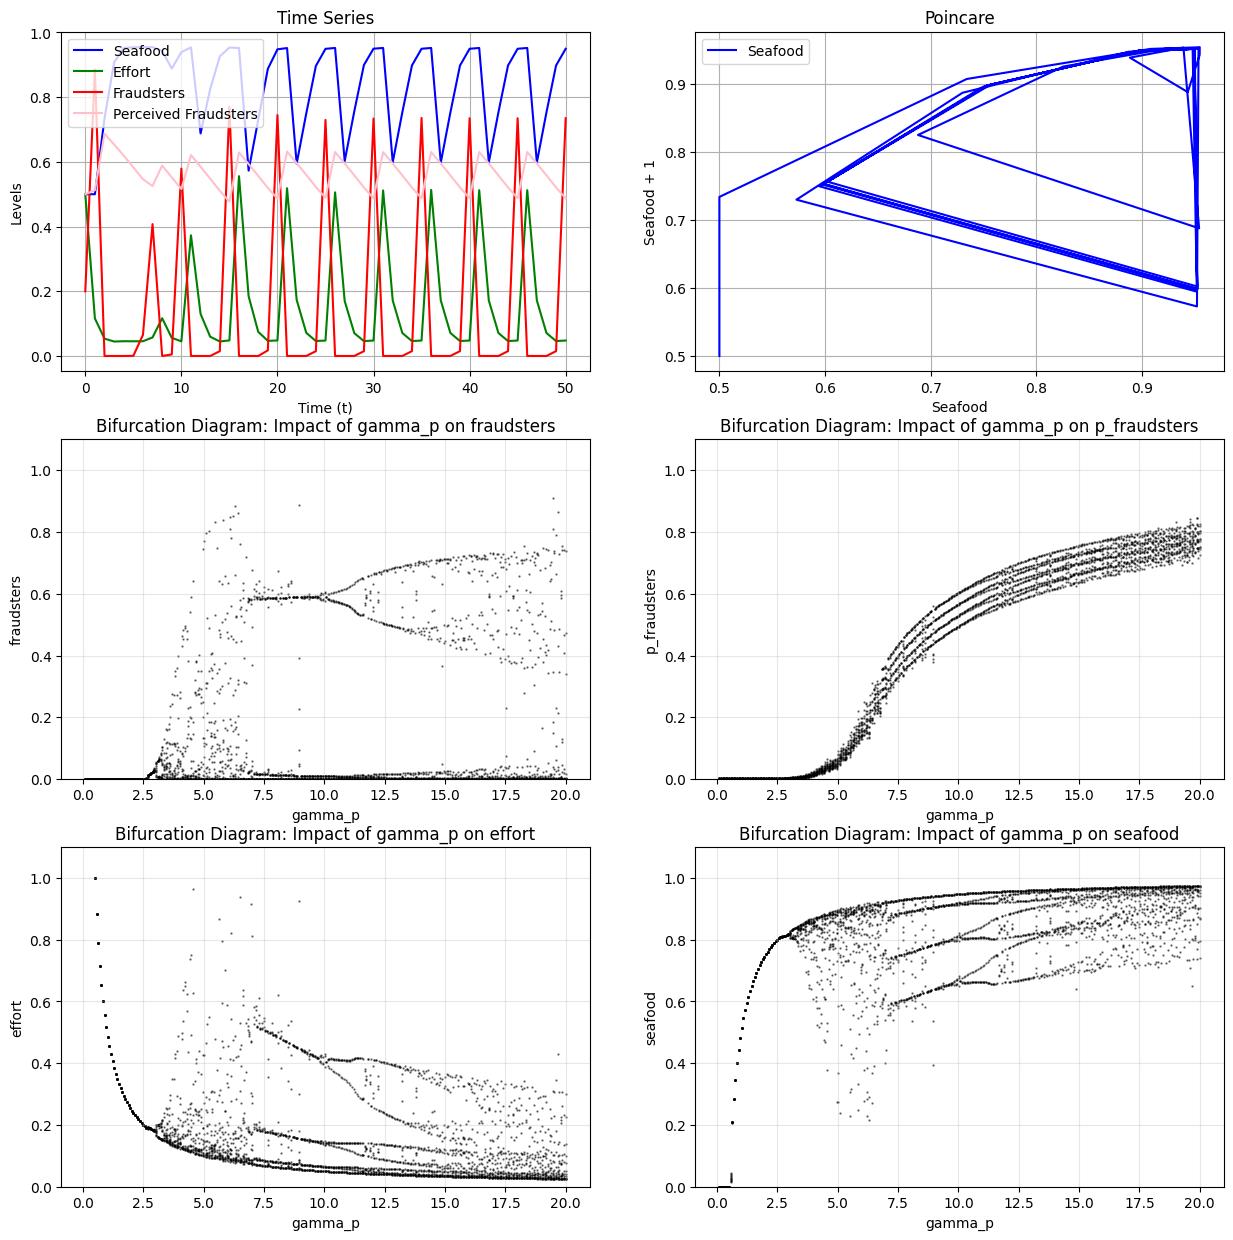

--- 1. Finding Fixed Points ---
Initial Guess: [0.5, 0.5, 0.2, 0.5]
Fixed Point Found (S*, E*, F*, Fp*): [0.5 0.5 0.2 0.5]
Residuals (should be ~0): 7.86e-01

--- 2. Jacobian Matrix at Fixed Point ---
[[ 0.5    -0.5     0.      0.    ]
 [ 0.      0.1812 -0.215   0.    ]
 [ 0.0204  0.0204 -0.2874 -0.7154]
 [ 0.      0.      0.2498  0.9994]]

--- 3. Eigenvalues & Stability ---
Eigenvalues: [ 0.8405  0.5147 -0.0948  0.1328]
Magnitudes:  [0.8405 0.5147 0.0948 0.1328]

System Stability at Fixed Point: STABLE


/tmp/ipython-input-4001821470.py:33: RuntimeWarning: invalid value encountered in scalar power
  price_market = gamma_m * ((1 - Fp)**(e_d/2) / denom_market)
/tmp/ipython-input-229096759.py:138: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  fixed_point_root = fsolve(equations_to_zero, init_vals)


In [182]:
params = new_params_without_old_influence
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
y_lim = None

param_bifurcation = 'gamma_p'
param_range = [0.1, 20, 300]

def system_map(state, params):
    S, E, F, FP = state
    # Unpack parameters dictionary for clarity
    gamma_m = params['gamma_m']
    gamma_f = params['gamma_f']
    gamma_s = params['gamma_s']
    gamma_e = params['gamma_e']
    gamma_p = params['gamma_p']
    gamma_fp = params['gamma_fp']
    e_sm = params['e_sm']
    e_sw = params['e_sw']
    e_d = params['e_d']
    q = params['q']
    pw = params['pw']
    c = params['c']
    F_threshold = params['F_threshold']
    
    # Calculate next steps
    S_new = seafood_state(S, E, gamma_s)
    E_new = effort_state(E, S, F, q, pw, c, e_sw, gamma_p, gamma_e)
    F_new = fraudster_state(S, E, F, FP, gamma_f, gamma_m, gamma_p, pw, e_sw, e_sm, e_d)
    Fp_new = p_fraudster_state(F, FP, F_threshold, gamma_fp)
    return np.array([S_new, E_new, F_new, Fp_new])

def time_series(ax, params, initial_vals, time=total_time):
    seafood, effort, fraudsters, p_fraudsters = np.array([initial_vals[0]], dtype=np.longdouble), np.array([initial_vals[1]], dtype=np.longdouble), np.array([initial_vals[2]], dtype=np.longdouble), np.array([initial_vals[3]], dtype=np.longdouble)
    time_period = []
    for i in range(time):
        time_period.append(i)
        seafood = np.append(seafood, seafood_state(seafood[i], effort[i], params['gamma_s']))
        effort = np.append(effort, effort_state(effort[i], seafood[i], fraudsters[i], params['q'], params['pw'], params['c'], params['e_sw'], params['gamma_p'], params['gamma_e']))
        fraudsters = np.append(fraudsters, fraudster_state(seafood[i], effort[i], fraudsters[i], p_fraudsters[i], params['gamma_f'], params['gamma_m'], params['gamma_p'], params['pw'], params['e_sw'], params['e_sm'], params['e_d']))
        p_fraudsters = np.append(p_fraudsters, p_fraudster_state(fraudsters[i], p_fraudsters[i], params['F_threshold'], params['gamma_fp']))
    time_period.append(time)
            
    line_graph([time_period, time_period, time_period, time_period], [seafood, effort, fraudsters, p_fraudsters], ax, title=f"Time Series", y_label="Levels", x_label="Time (t)", line_label=["Seafood", "Effort", "Fraudsters", "Perceived Fraudsters"], line_color=["Blue", "green", "red", "pink"], y_lim=y_lim)

def bifurcation(ax, param_name, param_linspace, y_state_var):
    # Transient should be less than steps
    def run_system(params, steps=total_time, transient=bifurcation_transient):
        # Initial starting points
        S, E, F, FP = init_vals
        
        trajectory = []
        
        for t in range(steps):
            # Update
            S_new = seafood_state(S, E, params['gamma_s'])
            E_new = effort_state(E, S, F, params['q'], params['pw'], params['c'], 
                                params['e_sw'], params['gamma_p'], params['gamma_e'])
            F_new = fraudster_state(S, E, F, FP, params['gamma_f'], params['gamma_m'], 
                                    params['gamma_p'], params['pw'], params['e_sw'], 
                                    params['e_sm'], params['e_d'])
            FP_new = p_fraudster_state(F, FP, params['F_threshold'], params['gamma_fp'])
            
            # Safety Clip
            S, E, F, FP = np.maximum([S_new, E_new, F_new, FP_new], 1e-6)
            
            # Store only after transient period to see steady state behavior
            if t > transient:
                if y_state_var == "fraudsters":
                    trajectory.append(F)
                elif y_state_var == "p_fraudsters":
                    trajectory.append(FP)
                elif y_state_var == "seafood":
                    trajectory.append(S)
                elif y_state_var == "effort":
                    trajectory.append(E)
                
        return trajectory
    param_values = np.linspace(param_linspace[0], param_linspace[1], param_linspace[2])

    x_vals = []
    y_vals = []

    print(f"Generating Bifurcation Diagram for {param_name}...")

    for val in param_values:
        # Update param
        current_params = params.copy()
        current_params[param_name] = val
        
        # Run
        points = run_system(current_params)
        
        # Append to lists
        for p in points:
            x_vals.append(val)
            y_vals.append(p)

    # Plot
    ax.scatter(x_vals, y_vals, s=0.5, c='black', alpha=0.5)
    ax.set_title(f'Bifurcation Diagram: Impact of {param_name} on {y_state_var}')
    ax.set_xlabel(param_name)
    ax.set_ylabel(y_state_var)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3)

def stability_analysis():
    def equations_to_zero(x):
        """
        For fixed points, we want X_{t+1} - X_{t} = 0.
        """
        # Enforce non-negativity with absolute value for physical feasibility 
        # during solver steps (optional but helps stability)
        x_safe = np.abs(x) 
        return system_map(x_safe, params) - x_safe

    def compute_jacobian(func, x, epsilon=1e-6):
        """
        Computes the Jacobian matrix numerically using central differences.
        J_ij = d(f_i)/d(x_j)
        """
        n = len(x)
        J = np.zeros((n, n))
        
        for j in range(n):
            perturb = np.zeros(n)
            perturb[j] = epsilon
            
            # Central difference: (f(x+h) - f(x-h)) / 2h
            f_plus = func(x + perturb, params)
            f_minus = func(x - perturb, params)
            
            J[:, j] = (f_plus - f_minus) / (2 * epsilon)
            
        return J

    print("--- 1. Finding Fixed Points ---")
    # Find the root (Fixed Point) starting from init_vals
    fixed_point_root = fsolve(equations_to_zero, init_vals)

    # Validate the solution (Check if residuals are close to zero)
    residuals = equations_to_zero(fixed_point_root)
    print(f"Initial Guess: {init_vals}")
    print(f"Fixed Point Found (S*, E*, F*, Fp*): {np.round(fixed_point_root, 4)}")
    print(f"Residuals (should be ~0): {np.linalg.norm(residuals):.2e}")

    print("\n--- 2. Jacobian Matrix at Fixed Point ---")
    # Calculate Jacobian at the found fixed point
    J = compute_jacobian(system_map, fixed_point_root)

    # Formatting for cleaner output
    np.set_printoptions(precision=4, suppress=True)
    print(J)

    print("\n--- 3. Eigenvalues & Stability ---")
    evals = eigvals(J)
    print(f"Eigenvalues: {evals}")

    # Check stability (Discrete time: Magnitude < 1 implies stability)
    magnitudes = np.abs(evals)
    print(f"Magnitudes:  {magnitudes}")

    is_stable = all(m < 1.0 for m in magnitudes)
    print(f"\nSystem Stability at Fixed Point: {'STABLE' if is_stable else 'UNSTABLE'}")

def poincare(ax, params, initial_vals, time=total_time):
    seafood, effort, fraudsters, p_fraudsters = np.array([initial_vals[0]], dtype=np.longdouble), np.array([initial_vals[1]], dtype=np.longdouble), np.array([initial_vals[2]], dtype=np.longdouble), np.array([initial_vals[3]], dtype=np.longdouble)
    time_period = []
    for i in range(time):
        time_period.append(i)
        seafood = np.append(seafood, seafood_state(seafood[i], effort[i], params['gamma_s']))
        effort = np.append(effort, effort_state(effort[i], seafood[i], fraudsters[i], params['q'], params['pw'], params['c'], params['e_sw'], params['gamma_p'], params['gamma_e']))
        fraudsters = np.append(fraudsters, fraudster_state(seafood[i], effort[i], fraudsters[i], p_fraudsters[i], params['gamma_f'], params['gamma_m'], params['gamma_p'], params['pw'], params['e_sw'], params['e_sm'], params['e_d']))
        p_fraudsters = np.append(p_fraudsters, p_fraudster_state(fraudsters[i], p_fraudsters[i], params['F_threshold'], params['gamma_fp']))
    time_period.append(time)
         
    # For seafood
    line_graph([seafood[:-1]], [seafood[1:]], ax, title=f"Poincare", y_label="Seafood + 1", x_label="Seafood", line_label=["Seafood"], line_color=["Blue"], y_lim=y_lim)


time_series(axs[0][0], params, init_vals)
poincare(axs[0][1], params, init_vals)
bifurcation(axs[1][0], param_bifurcation, param_range, 'fraudsters')
bifurcation(axs[1][1], param_bifurcation, param_range, 'p_fraudsters')
bifurcation(axs[2][0], param_bifurcation, param_range, 'effort')
bifurcation(axs[2][1], param_bifurcation, param_range, 'seafood')
plt.show()
stability_analysis()

In [ ]:
execute(, , , , , , )
execute(,, ,, , ,,  )